In [8]:
import os
import sys
import json
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
sys.path.append("..")
# read from json
data = None
figure_name_prefix = "../figures/"
figure_name_suffix = "fig10c"

data_path = "../../../output/oscar-nsdi26/experiments/" + \
    figure_name_suffix+"/"
experiment_names = ["oscar", "hpcc", "hpcc-target1.5", "powertcp-12", "theta-powertcp", "poseidon", "dcqcn", "swift-25"]
experiment_suffix = ""

flow_size_group = [{
    "name": "Total",
    "size": [0, 1e9]
},
    {
        "name": "Hadoop",
        "size": [0, 150*1024]
},
    {
        "name": "Incast",
        "size": [150*1024, 1e9]
},
    {
        "name": "(3MB,)",
        "size": [3*1024*1024, 1e9]
},
]
slowdowns = [[] for i in range(len(experiment_names))]
avg_slowdowns = [[] for i in range(len(experiment_names))]
avg_fcts = [[] for i in range(len(experiment_names))]
p99_slowdowns = [[] for i in range(len(experiment_names))]
p99_fcts = [[] for i in range(len(experiment_names))]

In [9]:
for exp_idx, experiment_name in enumerate(experiment_names):

    with open(data_path + experiment_name + experiment_suffix + ".json", "r") as f:
        data = json.load(f)

    # group data:"flowStatistics":[:] by data:"flowStatistics":"flowType"
    flow_types = [g["name"] for g in flow_size_group]
    flows = [[] for i in range(len(flow_types))]
    for flow in data["flowStatistics"]:
        if flow["totalSizeBytes"] == 0:
            continue
        # find group of the flow by flow size
        for g in flow_size_group:
            if g["name"] == "Incast":
                if flow["flowType"] == "Incast":
                    flows[flow_size_group.index(g)].append(flow)
                continue
            if g["name"] == "Hadoop":
                if flow["flowType"] == "Background":
                    flows[flow_size_group.index(g)].append(flow)
                continue
            if flow["totalSizeBytes"] > g["size"][0] and flow["totalSizeBytes"] <= g["size"][1]:
                flows[flow_size_group.index(g)].append(flow)
                # break

    # calculate the fct slowdown according to the data:"flowStatistics":[:]:"totalSizeBytes"
    flow_slowdown = [[] for i in range(len(flow_types))]
    fcts = [[] for i in range(len(flow_types))]
    tor_rtt = 4e3
    pod_rtt = 8e3
    full_rtt = 12e3
    tor_size = 16
    pod_size = 64
    for i in range(len(flow_types)):
        for flow in flows[i]:
            total_size_bytes = flow["totalSizeBytes"]
            fct = flow["fctNs"]
            # calculate the rtt according the ip addr distance
            rtt = 0
            src_ip = flow["flowIdentifier"]["srcAddr"]
            dst_ip = flow["flowIdentifier"]["dstAddr"]
            # convert ip to int
            src_ip = int(src_ip.split(".")[2])*256 + int(src_ip.split(".")[3])
            dst_ip = int(dst_ip.split(".")[2])*256 + int(dst_ip.split(".")[3])
            # calculate the relation between src and dst
            if src_ip // tor_size == dst_ip // tor_size:
                rtt = tor_rtt
            elif src_ip // pod_size == dst_ip // pod_size:
                rtt = pod_rtt
            else:
                rtt = full_rtt
            slowdown = fct / (total_size_bytes * 8 / 100e9 * 1e9 + rtt)
            flow_slowdown[i].append(slowdown)
            fcts[i].append(fct/1e6) # ms

    # calculate the average slowdown and the p99 slowdowns
    avg_slowdown = []
    p99_slowdown = []
    avg_fct = []
    p99_fct = []
    for i in range(len(flow_types)):
        avg_fct.append(np.mean(fcts[i]))
        p99_fct.append(np.percentile(fcts[i], 99))
        
    for i in range(len(flow_types)):
        avg_slowdown.append(np.mean(flow_slowdown[i]))
        p99_slowdown.append(np.percentile(flow_slowdown[i], 99))
    
    slowdowns[exp_idx] = flow_slowdown
    avg_slowdowns[exp_idx] = avg_slowdown
    p99_slowdowns[exp_idx] = p99_slowdown
    avg_fcts[exp_idx] = avg_fct
    p99_fcts[exp_idx] = p99_fct


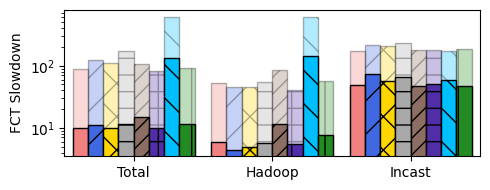

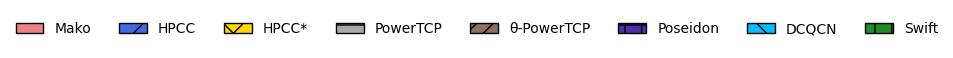

In [10]:


hatches = ['', '/', 'x', '-', '//', '+', '\\', '|', '*']
colors = ['#f18181', '#4068e1', '#ffd700', '#a9a9a9',
          '#8D6E63', '#512DA8', '#00bfff', '#228b22', '#F2C3A7']

experiment_names_in_fig = ["Mako", "HPCC", "HPCC*", "PowerTCP", "θ-PowerTCP", "Poseidon", "DCQCN", "Swift"]
exp_is = list(range(len(experiment_names)))

# plot the line figure of average slowdown and p99 slowdown in one figure
fig, ax = plt.subplots(1, 1, figsize=(5, 2))

num_groups = 3
num_bars_per_group = len(exp_is)
# width of each bar
bar_width = 0.11

group_positions = np.arange(num_groups)
offset = (num_bars_per_group - 1) / 2 * bar_width
bar_positions = [group_positions - offset + i *
                 bar_width for i in range(num_bars_per_group)]


def to_bar_log_slowdown(slowdown):
    # 0-4 are normal scale, other are log scale
    # if slowdown <= 2:
    #     return slowdown
    # else:
    #     return 2 + np.log10(slowdown) - np.log10(2)
    # return np.log10(slowdown)
    return slowdown


index = 0
labels = [experiment_names_in_fig[i] for i in exp_is]
for bar_idx, i in enumerate(exp_is):
    plt.bar(bar_positions[index], p99_slowdowns[i][:-1],
            width=bar_width, linestyle='-', edgecolor='black', hatch=hatches[index % len(hatches)], color=colors[index % len(colors)], alpha=0.3)
    plt.bar(bar_positions[index], avg_slowdowns[i][:-1], width=bar_width,
            linestyle='-', edgecolor='black', hatch=hatches[index % len(hatches)], color=colors[index % len(colors)], label=labels[bar_idx])
    index += 1

ax.set_ylabel("FCT Slowdown")
xticks = [i-0.065 for i in range(num_groups)]
ax.set_xlim(-0.5, num_groups-1+0.5)
ax.set_xticks(group_positions)
xticklabels = ["Total", "Hadoop", "Incast"]
ax.set_xticklabels(xticklabels)

ax.set_yscale("log")
plt.tight_layout()
plt.savefig(figure_name_prefix + figure_name_suffix + experiment_suffix +
            ".pdf", bbox_inches='tight', dpi=600, format='pdf')

fig_legend, ax_legend = plt.subplots(1, 1, figsize=(6, 0.5))
ax_legend.axis('off')
ax_legend.legend(*ax.get_legend_handles_labels(), loc='center',
                 ncol=len(experiment_names), frameon=False)
fig_legend.savefig(figure_name_prefix + figure_name_suffix + experiment_suffix +
                   "-legend.pdf", bbox_inches='tight', dpi=600, format='pdf')